In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generamos los datos del caso para el diagnóstico
datos = {
    'Mes': ['Oct', 'Nov', 'Dic', 'Ene', 'Feb', 'Mar'],
    'Rendimiento_Proyectos': [95, 88, 70, 60, 45, 40], # % de cumplimiento
    'Tickets_Soporte': [15, 22, 45, 70, 95, 120]      # Cantidad de incidencias
}

df = pd.DataFrame(datos)

# Un pequeño check para ver si hay relación (Insight)
print("Análisis inicial de correlación:")
print(df.corr(numeric_only=True))

Análisis inicial de correlación:
                       Rendimiento_Proyectos  Tickets_Soporte
Rendimiento_Proyectos               1.000000        -0.983769
Tickets_Soporte                    -0.983769         1.000000


In [3]:
# 1. Inspección de tipos de datos (Dtypes)
print("--- Estructura Técnica de las Variables ---")
print(df.dtypes)

# 2. Clasificación conceptual
# Creamos un pequeño diccionario descriptivo para tu documentación
estructura_analisis = {
    "Variable": ["Mes", "Rendimiento_Proyectos", "Tickets_Soporte"],
    "Tipo_Dato": ["Cualitativa Ordinal", "Cuantitativa Discreta", "Cuantitativa Discreta"],
    "Rol": ["Dimensión Temporal", "Métrica de Desempeño", "Causa Probable"]
}

df_estructura = pd.DataFrame(estructura_analisis)
print("\n--- Clasificación para el Proyecto ---")
display(df_estructura)

# 3. Validación de la estructura temporal
# Para que Python entienda que 'Mes' es tiempo, podrías convertirlo (opcional pero profesional)
# Aunque para este ejercicio, mantenerlo como string ordinal es suficiente.

--- Estructura Técnica de las Variables ---
Mes                      object
Rendimiento_Proyectos     int64
Tickets_Soporte           int64
dtype: object

--- Clasificación para el Proyecto ---


,Variable,Tipo_Dato,Rol
0,Mes,Cualitativa Ordinal,Dimensión Temporal
1,Rendimiento_Proyectos,Cuantitativa Discreta,Métrica de Desempeño
2,Tickets_Soporte,Cuantitativa Discreta,Causa Probable


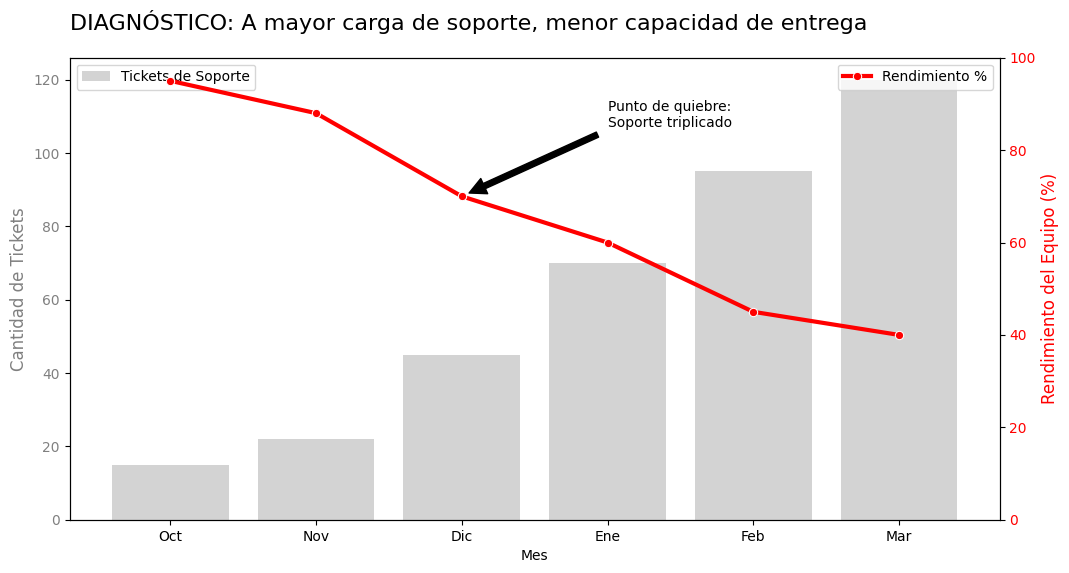

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos la figura y el primer eje (ax1)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Graficamos los Tickets como BARRAS (Gris para que no distraigan demasiado)
sns.barplot(x='Mes', y='Tickets_Soporte', data=df, ax=ax1, color='lightgray', label='Tickets de Soporte')
ax1.set_ylabel('Cantidad de Tickets', color='gray', fontsize=12)
ax1.tick_params(axis='y', labelcolor='gray')

# Creamos el segundo eje (ax2) para el Rendimiento
ax2 = ax1.twinx()
sns.lineplot(x='Mes', y='Rendimiento_Proyectos', data=df, ax=ax2, color='red', marker='o', linewidth=3, label='Rendimiento %')
ax2.set_ylabel('Rendimiento del Equipo (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 100) # El rendimiento siempre se entiende mejor de 0 a 100

# Aplicando principios de limpieza y foco (Lección 4)
plt.title('DIAGNÓSTICO: A mayor carga de soporte, menor capacidad de entrega', fontsize=16, loc='left', pad=20)
ax1.grid(False) # Limpiamos ruido visual
ax2.grid(False)

# Anotación del Insight clave
plt.annotate('Punto de quiebre:\nSoporte triplicado', xy=(2, 70), xytext=(3, 85),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, color='black')

plt.show()

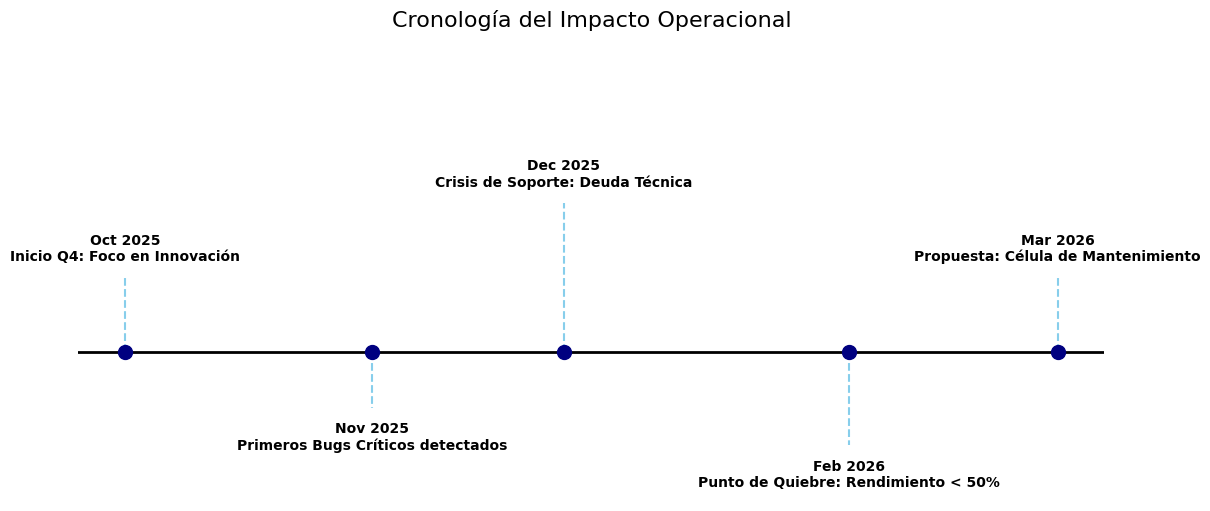

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definimos los hitos de nuestra historia (Datos Temporales)
eventos = {
    "Fecha": ["2025-10-01", "2025-11-15", "2025-12-20", "2026-02-10", "2026-03-20"],
    "Hito": ["Inicio Q4: Foco en Innovación", 
             "Primeros Bugs Críticos detectados", 
             "Crisis de Soporte: Deuda Técnica", 
             "Punto de Quiebre: Rendimiento < 50%", 
             "Propuesta: Célula de Mantenimiento"]
}

df_timeline = pd.DataFrame(eventos)
df_timeline['Fecha'] = pd.to_datetime(df_timeline['Fecha'])

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

# 1. Mantenemos la línea en 0, pero ajustamos el "suelo" y "techo" del gráfico
# Al poner un número alto en el segundo parámetro (8), la línea 0 se desplaza hacia abajo
ax.set_ylim(-4, 8) 

ax.axhline(0, color="black", linewidth=2, zorder=1)

# 2. Ajustamos niveles para que nada choque
levels = [2, -1.5, 4, -2.5, 2] 

ax.vlines(df_timeline['Fecha'], 0, levels, color="skyblue", linestyle="--")
ax.scatter(df_timeline['Fecha'], [0]*len(df_timeline), c="navy", s=100, zorder=3)

for i, (date, hito) in enumerate(zip(df_timeline['Fecha'], df_timeline['Hito'])):
    va_type = "bottom" if levels[i] > 0 else "top"
    ax.annotate(f"{date.strftime('%b %Y')}\n{hito}", xy=(date, levels[i]),
                xytext=(0, 10 if levels[i] > 0 else -10), 
                textcoords="offset points", ha="center", 
                va=va_type, fontsize=10, fontweight='bold')

# Limpieza total para que se vea minimalista (Requerimiento Lección 4)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.title("Cronología del Impacto Operacional", fontsize=16, pad=20)
plt.show()

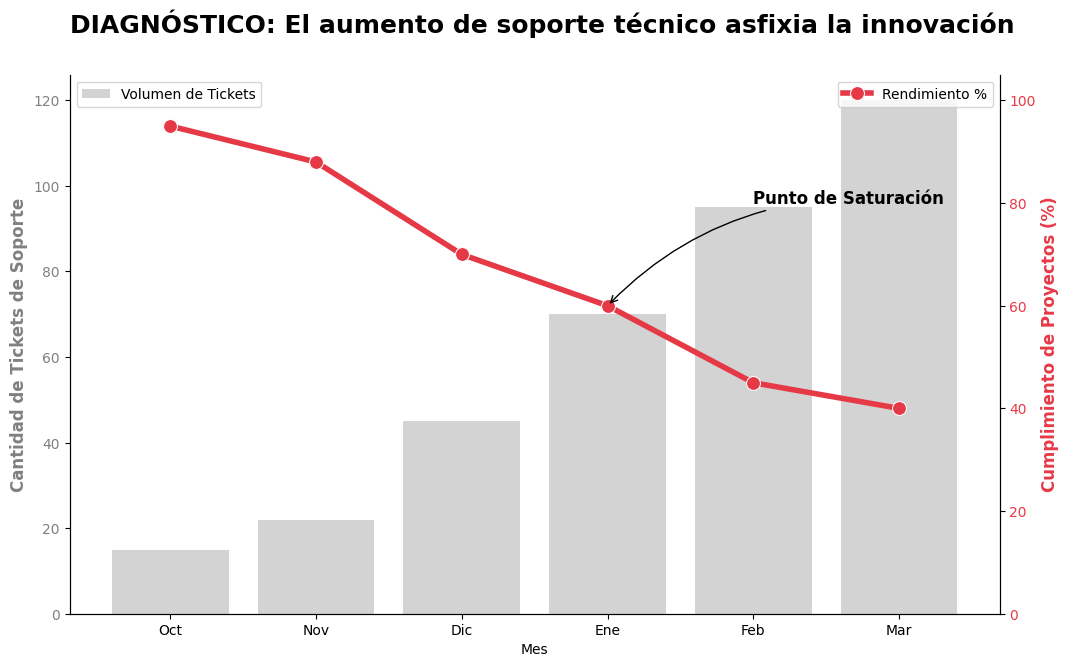

In [10]:
# Usamos el dataframe 'df' de la Lección 1
fig, ax1 = plt.subplots(figsize=(12, 7))

# Marca Visual 1: BARRAS para los Tickets (Gris = Contexto/Causa)
sns.barplot(x='Mes', y='Tickets_Soporte', data=df, ax=ax1, color='#D3D3D3', label='Volumen de Tickets')
ax1.set_ylabel('Cantidad de Tickets de Soporte', fontsize=12, fontweight='bold', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# Marca Visual 2: LÍNEA para el Rendimiento (ROJO = Alerta/Insight)
ax2 = ax1.twinx()
sns.lineplot(x='Mes', y='Rendimiento_Proyectos', data=df, ax=ax2, 
             color='#E63946', marker='o', markersize=10, linewidth=4, label='Rendimiento %')
ax2.set_ylabel('Cumplimiento de Proyectos (%)', fontsize=12, fontweight='bold', color='#E63946')
ax2.tick_params(axis='y', labelcolor='#E63946')
ax2.set_ylim(0, 105)

# Limpieza de ruido visual (Manual 4)
ax1.grid(False)
ax2.grid(False)
sns.despine(right=False)

# Título con el Insight explícito (Storytelling)
plt.title('DIAGNÓSTICO: El aumento de soporte técnico asfixia la innovación', 
          fontsize=18, loc='left', pad=30, fontweight='bold')

# Flecha de anotación para el "Insight"
ax2.annotate('Punto de Saturación', xy=(3, 60), xytext=(4, 80),
             arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=.2"),
             fontsize=12, fontweight='bold')

plt.show()